<a href="https://colab.research.google.com/github/realasa23/PBA5026231113/blob/main/EDA_FeatExt_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import IPython
nb = IPython.get_ipython()

# Fix widget metadata
import json, os
nb_path = None

# Cara fix via post-save hook atau langsung edit file setelah download
# Tapi cara paling simpel: hapus widget metadata sebelum push ke GitHub

# Inisiasi

In [ ]:
!pip install deep-translator textblob
!pip install -q pandas matplotlib seaborn scikit-learn transformers torch openpyxl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import warnings
import subprocess, sys
from google.colab import files
from textblob import TextBlob
from deep_translator import GoogleTranslator
from sklearn.metrics import accuracy_score, classification_report, f1_score
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from transformers import pipeline


In [ ]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [ ]:
# Upload dan Load Data
github_url = 'https://raw.githubusercontent.com/cafauzi13/ESG_SentimentAnalysis/764b33f6a6cff64b5533c58e5eec809d8eb68cb9/data/clean_data.csv'

try:
    df = pd.read_csv(github_url)
    print(f'✅ Dataset berhasil di-load! Total data: {df.shape[0]} baris.')
except Exception as e:
    print(f'❌ Gagal load data!. Error: {e}')


✅ Dataset berhasil di-load! Total data: 468 baris.


In [ ]:
display(df.head())

,Link,Sentiment,Penerbit,Tag,Perusahaan,Tahun,Isi Berita Clean,teks_bersih,tokens,jumlah_token
0,https://finansial.bisnis.com/read/20230908/90/...,Positif,Bisnis.com,Finance,Bank BRI,2023,Sukses dalam transisi energi menjadi salah tuj...,sukses dalam transisi energi menjadi salah tuj...,"[""sukses"", ""transisi"", ""energi"", ""salah"", ""tuj...",222
1,https://finansial.bisnis.com/read/20231108/90/...,Positif,Bisnis.com,Governance,Bank Mandiri,2023,Bank Mandiri berhasil mencetak pertumbuhan lab...,bank mandiri berhasil mencetak pertumbuhan lab...,"[""bank"", ""mandiri"", ""hasil"", ""cetak"", ""tumbuh""...",362
2,https://finansial.bisnis.com/read/20250206/90/...,Positif,Bisnis.com,Finance,Bank Mandiri,2023,Bank Mandiri terus memperkuat perannya dalam m...,bank mandiri terus memperkuat perannya dalam m...,"[""bank"", ""mandiri"", ""kuat"", ""peran"", ""optimal""...",797
3,https://finansial.bisnis.com/read/20250209/90/...,Positif,Bisnis.com,Environment,Bank Mandiri,2025,Bank Mandiri kembali menunjukkan komitmennya d...,bank mandiri kembali menunjukkan komitmennya d...,"[""bank"", ""mandiri"", ""komitmen"", ""dukung"", ""per...",432
4,https://keuangan.kontan.co.id/news/green-finan...,Positif,Kontan,Finance,Bank BSI,2025,PT Bank Syariah Indonesia Tbk (BSI) berkomitme...,pt bank syariah indonesia tbk bsi berkomitmen ...,"[""pt"", ""bank"", ""syariah"", ""indonesia"", ""tbk"", ...",252


# EDA

In [ ]:
# Cek Kualitas Data Dasar
print("\n=== RINGKASAN DATA ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df[['teks_bersih', 'Sentiment', 'Tag']].isnull().sum())
df = df.dropna(subset=['teks_bersih']).reset_index(drop=True)

# Tambahkan metrik panjang kata
df['panjang_kata'] = df['teks_bersih'].apply(lambda x: len(str(x).split()))

print("\n--- Ringkasan Data ---")
print(df.info())
display(df.head())


=== RINGKASAN DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Link              468 non-null    object
 1   Sentiment         468 non-null    object
 2   Penerbit          429 non-null    object
 3   Tag               468 non-null    object
 4   Perusahaan        182 non-null    object
 5   Tahun             199 non-null    object
 6   Isi Berita Clean  468 non-null    object
 7   teks_bersih       468 non-null    object
 8   tokens            468 non-null    object
 9   jumlah_token      468 non-null    int64 
dtypes: int64(1), object(9)
memory usage: 36.7+ KB
None

=== MISSING VALUES ===
teks_bersih    0
Sentiment      0
Tag            0
dtype: int64

--- Ringkasan Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 


,Link,Sentiment,Penerbit,Tag,Perusahaan,Tahun,Isi Berita Clean,teks_bersih,tokens,jumlah_token,panjang_kata
0,https://finansial.bisnis.com/read/20230908/90/...,Positif,Bisnis.com,Finance,Bank BRI,2023,Sukses dalam transisi energi menjadi salah tuj...,sukses dalam transisi energi menjadi salah tuj...,"[""sukses"", ""transisi"", ""energi"", ""salah"", ""tuj...",222,349
1,https://finansial.bisnis.com/read/20231108/90/...,Positif,Bisnis.com,Governance,Bank Mandiri,2023,Bank Mandiri berhasil mencetak pertumbuhan lab...,bank mandiri berhasil mencetak pertumbuhan lab...,"[""bank"", ""mandiri"", ""hasil"", ""cetak"", ""tumbuh""...",362,549
2,https://finansial.bisnis.com/read/20250206/90/...,Positif,Bisnis.com,Finance,Bank Mandiri,2023,Bank Mandiri terus memperkuat perannya dalam m...,bank mandiri terus memperkuat perannya dalam m...,"[""bank"", ""mandiri"", ""kuat"", ""peran"", ""optimal""...",797,1255
3,https://finansial.bisnis.com/read/20250209/90/...,Positif,Bisnis.com,Environment,Bank Mandiri,2025,Bank Mandiri kembali menunjukkan komitmennya d...,bank mandiri kembali menunjukkan komitmennya d...,"[""bank"", ""mandiri"", ""komitmen"", ""dukung"", ""per...",432,632
4,https://keuangan.kontan.co.id/news/green-finan...,Positif,Kontan,Finance,Bank BSI,2025,PT Bank Syariah Indonesia Tbk (BSI) berkomitme...,pt bank syariah indonesia tbk bsi berkomitmen ...,"[""pt"", ""bank"", ""syariah"", ""indonesia"", ""tbk"", ...",252,364


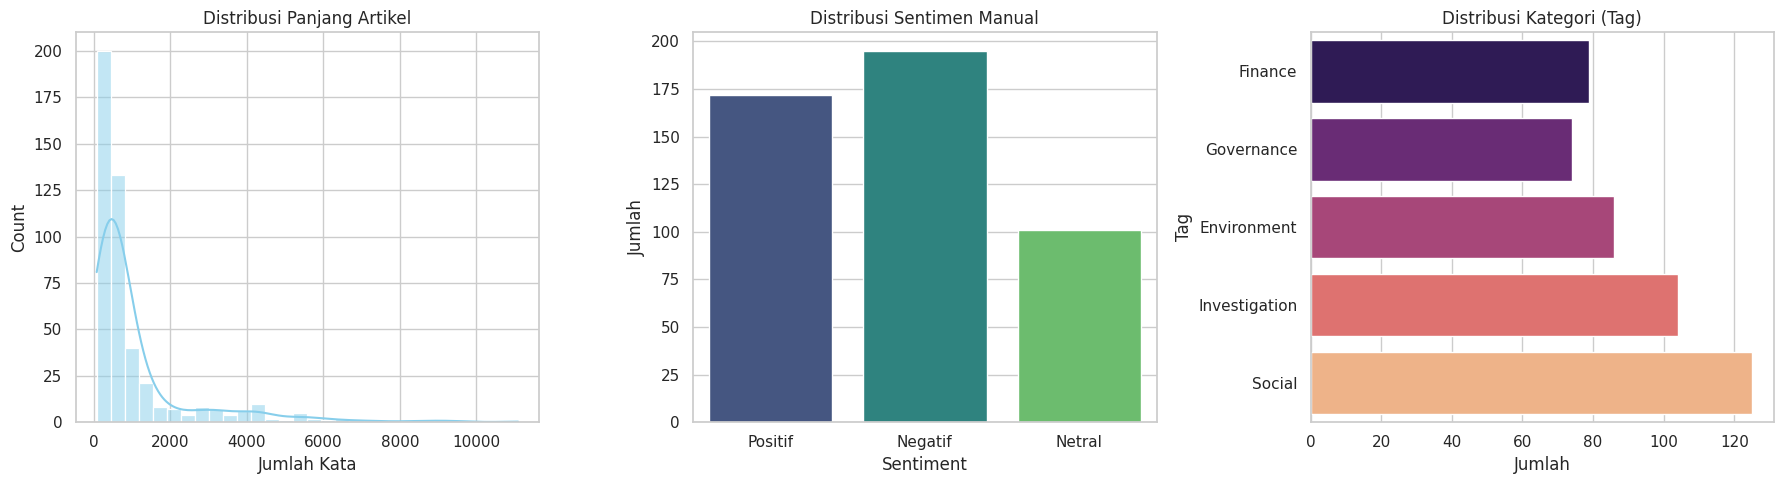

In [ ]:
# 3. Visualisasi EDA Dasar
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Distribusi Panjang Kata
sns.histplot(df['panjang_kata'], kde=True, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Panjang Artikel')
axes[0].set_xlabel('Jumlah Kata')

# Plot B: Distribusi Sentimen
sns.countplot(data=df, x='Sentiment', palette='viridis', order=['Positif', 'Negatif', 'Netral'], ax=axes[1])
axes[1].set_title('Distribusi Sentimen Manual')
axes[1].set_ylabel('Jumlah')

# Plot C: Distribusi Kategori (Tag)
sns.countplot(data=df, y='Tag', palette='magma', ax=axes[2])
axes[2].set_title('Distribusi Kategori (Tag)')
axes[2].set_xlabel('Jumlah')

plt.tight_layout()
plt.show()


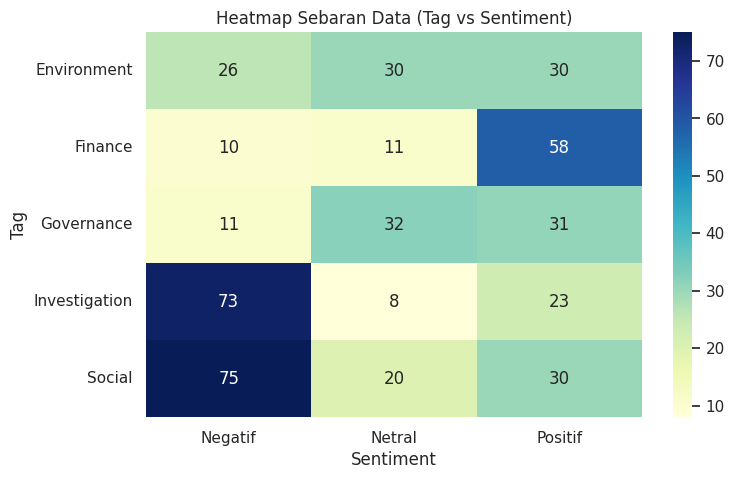

In [ ]:
# 4. Tabel Silang (Cross-Tabulation) & Heatmap
cross_tab = pd.crosstab(df['Tag'], df['Sentiment'])
plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap Sebaran Data (Tag vs Sentiment)')
plt.show()

In [ ]:
# 5. GATE KEPUTUSAN (PIPELINE B5)
def gate_keputusan_b5(dataframe, min_target=15):
    print("\n" + "="*40)
    print("🚦 GATE B5: STATUS KEBUTUHAN DATA")
    print("="*40)

    ct = pd.crosstab(dataframe['Tag'], dataframe['Sentiment'])
    kekurangan_data = []

    for tag in ct.index:
        for sent in ct.columns:
            jumlah = ct.loc[tag, sent]
            if jumlah < min_target:
                butuh = min_target - jumlah
                kekurangan_data.append({'Tag': tag, 'Sentimen': sent, 'Kurang': butuh})

    if not kekurangan_data:
        print("✅ STATUS: AMAN. Lanjut ke ekstraksi fitur (TF-IDF/POS Tagging).")
    else:
        print("⚠️ STATUS: BUTUH TAMBAHAN ARTIKEL!")
        print("Silakan infokan ke Pipeline A (Tim Scraping) untuk mencari:")
        df_kurang = pd.DataFrame(kekurangan_data)
        display(df_kurang)

# Panggil fungsi gate keputusan
gate_keputusan_b5(df, min_target=5)


🚦 GATE B5: STATUS KEBUTUHAN DATA
✅ STATUS: AMAN. Lanjut ke ekstraksi fitur (TF-IDF/POS Tagging).



### TEXTBLOB SENTIMENT (VIA TRANSLATION)


⏳ Memulai proses translasi ke Bahasa Inggris (Please wait yh)...
   Translasi baris ke-50 selesai...
   Translasi baris ke-100 selesai...
   Translasi baris ke-150 selesai...
   Translasi baris ke-200 selesai...
   Translasi baris ke-250 selesai...
   Translasi baris ke-300 selesai...
   Translasi baris ke-350 selesai...
   Translasi baris ke-400 selesai...
   Translasi baris ke-450 selesai...
✅ Translasi & Scoring selesai dalam 94.96 detik.


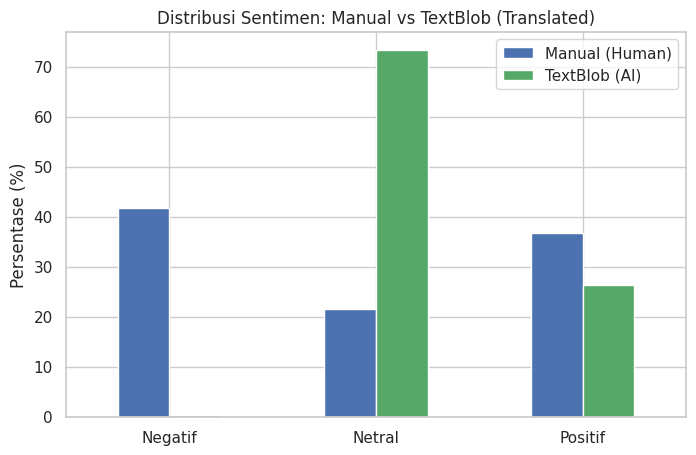

Unique Manual Labels: ['Positif' 'Negatif' 'Netral']
Unique TextBlob Labels: ['Netral' 'Positif' 'Negatif']

--- LAPORAN VALIDASI TEXTBLOB ---
Akurasi: 0.29
              precision    recall  f1-score   support

     Negatif       0.50      0.01      0.01       195
      Netral       0.18      0.61      0.28       101
     Positif       0.59      0.42      0.49       172

    accuracy                           0.29       468
   macro avg       0.42      0.35      0.26       468
weighted avg       0.46      0.29      0.24       468



In [ ]:
print("⏳ Memulai proses translasi ke Bahasa Inggris (Please wait yh)...")

# 1. Fungsi Translasi (Aman dari limit API Colab)
def translate_to_english(text):
    try:
        # Batasi 6000 karakter agar tidak error kena limit Google Translate
        text_sliced = str(text)[:6000]
        translated = GoogleTranslator(source='id', target='en').translate(text_sliced)
        return translated
    except Exception as e:
        return "" # Return kosong jika gagal

# 2. Fungsi TextBlob Scoring
def get_textblob_label(text):
    if not text: return 'Netral'

    score = TextBlob(text).sentiment.polarity
    if score > 0.1:
        return 'Positif'
    elif score < -0.1:
        return 'Negatif'
    else:
        return 'Netral'

# 3. Eksekusi Translasi & Scoring
# Gunakan progress_apply jika tqdm sudah diinstall (opsional), jika tidak pakai apply biasa
# Disini kita pakai .apply biasa tapi cetak progress per 50 baris
start_time = time.time()

english_texts = []
for i, text in enumerate(df['teks_bersih']):
    if i % 50 == 0 and i > 0:
        print(f"   Translasi baris ke-{i} selesai...")
    english_texts.append(translate_to_english(text))

df['Teks_English'] = english_texts
df['Sentiment_TextBlob'] = df['Teks_English'].apply(get_textblob_label)

print(f"✅ Translasi & Scoring selesai dalam {(time.time() - start_time):.2f} detik.")

# 4. Evaluasi & Visualisasi TextBlob
dist_manual = df['Sentiment'].value_counts(normalize=True) * 100
dist_blob = df['Sentiment_TextBlob'].value_counts(normalize=True) * 100

df_dist = pd.DataFrame({'Manual (Human)': dist_manual, 'TextBlob (AI)': dist_blob}).fillna(0)

plt.figure(figsize=(8, 5))
df_dist.plot(kind='bar', color=['#4C72B0', '#55A868'], ax=plt.gca())
plt.title('Distribusi Sentimen: Manual vs TextBlob (Translated)')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.show()

# 5. Laporan Performa TextBlob
df_clean = df.dropna(subset=['Sentiment', 'Sentiment_TextBlob']).copy()
df_clean['Sentiment'] = df_clean['Sentiment'].astype(str).str.strip()
df_clean['Sentiment_TextBlob'] = df_clean['Sentiment_TextBlob'].astype(str).str.strip()
print("Unique Manual Labels:", df_clean['Sentiment'].unique())
print("Unique TextBlob Labels:", df_clean['Sentiment_TextBlob'].unique())
print("\n--- LAPORAN VALIDASI TEXTBLOB ---")
print(f"Akurasi: {accuracy_score(df['Sentiment'], df['Sentiment_TextBlob']):.2f}")
print(classification_report(df['Sentiment'], df['Sentiment_TextBlob']))

In [ ]:
# Melihat 5 contoh yang manualnya Negatif tapi ditebak lain oleh AI
mask = (df['Sentiment'] == 'Negatif') & (df['Sentiment_TextBlob'] != 'Negatif')
print(df[mask][['teks_bersih', 'Teks_English', 'Sentiment', 'Sentiment_TextBlob']].head())

                                          teks_bersih  \
6   aliran kredit ke sektor batubara atau yang dij...   
7   perbankan dalam negeri tampaknya masih sulit u...   
8   penyaluran kredit perbankan ke sektor pertamba...   
9   penurunan permintaan sedang menerpa industri b...   
38  uang yang kita simpan di bank bukanlah sesuatu...   

                                         Teks_English Sentiment  \
6   The flow of credit to the coal sector, also kn...   Negatif   
7   Domestic banks still seem to find it difficult...   Negatif   
8   Bank Mandiri credit distribution to the coal m...   Negatif   
9   The decline in demand is hitting the coal indu...   Negatif   
38                                                      Negatif   

   Sentiment_TextBlob  
6              Netral  
7              Netral  
8             Positif  
9              Netral  
38             Netral  


### INSET LEXICON DENGAN NEGATION HANDLING

In [ ]:
inset_dict = {}   #inisialisasi

print("📂 Memuat InSet Lexicon dari GitHub...")
url_pos = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
url_neg = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

try:
    df_pos = pd.read_csv(url_pos, sep='\t', names=['word', 'weight'])
    df_neg = pd.read_csv(url_neg, sep='\t', names=['word', 'weight'])
    df_pos['weight'] = pd.to_numeric(df_pos['weight'], errors='coerce').fillna(0).astype(int)
    df_neg['weight'] = pd.to_numeric(df_neg['weight'], errors='coerce').fillna(0).astype(int)
    inset_dict = dict(zip(df_pos['word'], df_pos['weight']))
    inset_dict.update(dict(zip(df_neg['word'], df_neg['weight'])))
    print(f"✅ Lexicon termuat: {len(inset_dict)} kata.")
except Exception as e:
    print(f"❌ Gagal memuat Lexicon: {e}")
    print("⚠️  Scoring InSet dilewati — semua artikel akan diberi label 'Netral'.")


📂 Memuat InSet Lexicon dari GitHub...
✅ Lexicon termuat: 9075 kata.


In [ ]:
# 1. Fungsi Scoring dengan Negation Handling
def calculate_inset_score_with_negation(text):
    if not isinstance(text, str): return 0

    words = text.lower().split()
    negation_words = ['tidak', 'bukan', 'belum', 'jangan', 'kurang', 'tanpa']
    scores = []

    # Looping dengan index untuk mengecek kata sebelumnya (negation window = 1)
    for i, word in enumerate(words):
        if word in inset_dict:
            base_score = inset_dict[word]

            # Cek 1 kata sebelumnya apakah ada kata negasi
            is_negated = False
            if i > 0 and words[i-1] in negation_words:
                is_negated = True

            # Cek 2 kata sebelumnya (opsional, jika ingin window lebih lebar)
            elif i > 1 and words[i-2] in negation_words:
                is_negated = True

            # Balik polaritas jika kena negasi
            final_score = base_score * -1 if is_negated else base_score
            scores.append(final_score)

    # Hitung rata-rata skor agar panjang berita tidak merusak bobot
    return sum(scores) / len(scores) if len(scores) > 0 else 0


🚀 Menghitung skor sentimen (dilengkapi deteksi negasi)...


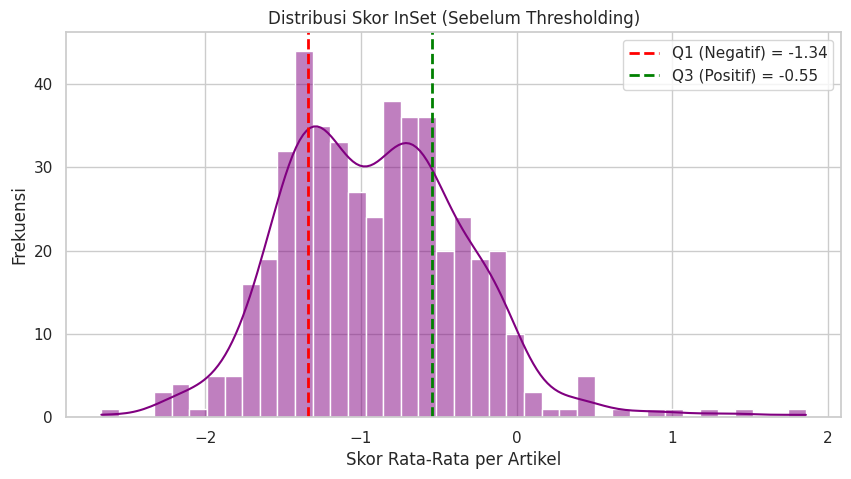

In [ ]:

# 2. Terapkan Fungsi dan Hitung Skor Mentah (Mean Score)
print("🚀 Menghitung skor sentimen (dilengkapi deteksi negasi)...")
df['InSet_Score'] = df['teks_bersih'].apply(calculate_inset_score_with_negation)

# 3. Hitung Kuartil untuk Statistical Thresholding
q1 = df['InSet_Score'].quantile(0.25)
q3 = df['InSet_Score'].quantile(0.75)

# 4. Visualisasi Distribusi Skor Murni
plt.figure(figsize=(10, 5))
sns.histplot(df['InSet_Score'], kde=True, bins=40, color='purple')
plt.axvline(q1, color='red', linestyle='--', linewidth=2, label=f'Q1 (Negatif) = {q1:.2f}')
plt.axvline(q3, color='green', linestyle='--', linewidth=2, label=f'Q3 (Positif) = {q3:.2f}')
plt.title('Distribusi Skor InSet (Sebelum Thresholding)')
plt.xlabel('Skor Rata-Rata per Artikel')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()


In [ ]:
# 5. Terapkan Label Final Berdasarkan Threshold
def apply_statistical_threshold(score):
    if score > q3:
        return 'Positif'
    elif score < q1:
        return 'Negatif'
    else:
        return 'Netral'

df['Sentiment_InSet'] = df['InSet_Score'].apply(apply_statistical_threshold)

# 6. Laporan Performa InSet
print("\n=== LAPORAN VALIDASI INSET LEXICON ===")
print(f"Akurasi terhadap Manual: {accuracy_score(df['Sentiment'], df['Sentiment_InSet']):.2f}")
print(classification_report(df['Sentiment'], df['Sentiment_InSet']))




=== LAPORAN VALIDASI INSET LEXICON ===
Akurasi terhadap Manual: 0.50
              precision    recall  f1-score   support

     Negatif       0.77      0.46      0.58       195
      Netral       0.26      0.60      0.36       101
     Positif       0.71      0.48      0.57       172

    accuracy                           0.50       468
   macro avg       0.58      0.52      0.51       468
weighted avg       0.64      0.50      0.53       468



### KESIMPULAN PERBANDINGAN F1-SCORE

In [ ]:
if 'Sentiment_TextBlob' in df.columns:
    f1_blob = f1_score(df['Sentiment'], df['Sentiment_TextBlob'], average='macro', zero_division=0)
    f1_inset = f1_score(df['Sentiment'], df['Sentiment_InSet'], average='macro', zero_division=0)

    print("\n" + "="*50)
    print("🏆 RINGKASAN PERBANDINGAN METODE VALIDASI")
    print("="*50)
    print(f"{'Metode':<20} | {'F1-Macro':<10} | {'Keterangan'}")
    print("-" * 50)
    print(f"{'TextBlob (Translated)':<20} | {f1_blob:<10.4f} | Rentan bias hasil translasi mesin")
    print(f"{'InSet (+ Negation)':<20} | {f1_inset:<10.4f} | Menangkap struktur B.Indonesia murni")




🏆 RINGKASAN PERBANDINGAN METODE VALIDASI
Metode               | F1-Macro   | Keterangan
--------------------------------------------------
TextBlob (Translated) | 0.2592     | Rentan bias hasil translasi mesin
InSet (+ Negation)   | 0.5052     | Menangkap struktur B.Indonesia murni


# Feature Extraction

### TF-IDF


⏳ [C0] Menghitung TF-IDF...
✅ Kolom 'teks_bersih' berhasil dikenali sebagai 'clean_text'

🔥 Top 20 Kata Berdasarkan TF-IDF:
energi           0.055378
bank             0.054783
indonesia        0.046967
perusahaan       0.046723
sawit            0.046004
antam            0.045816
mandiri          0.035333
pembiayaan       0.034953
berkelanjutan    0.034361
masyarakat       0.033524
lingkungan       0.032970
triliun          0.031920
sektor           0.031705
listrik          0.030786
warga            0.029856
mereka           0.029711
hijau            0.028338
bri              0.028061
kredit           0.027749
tambang          0.027389
dtype: float64


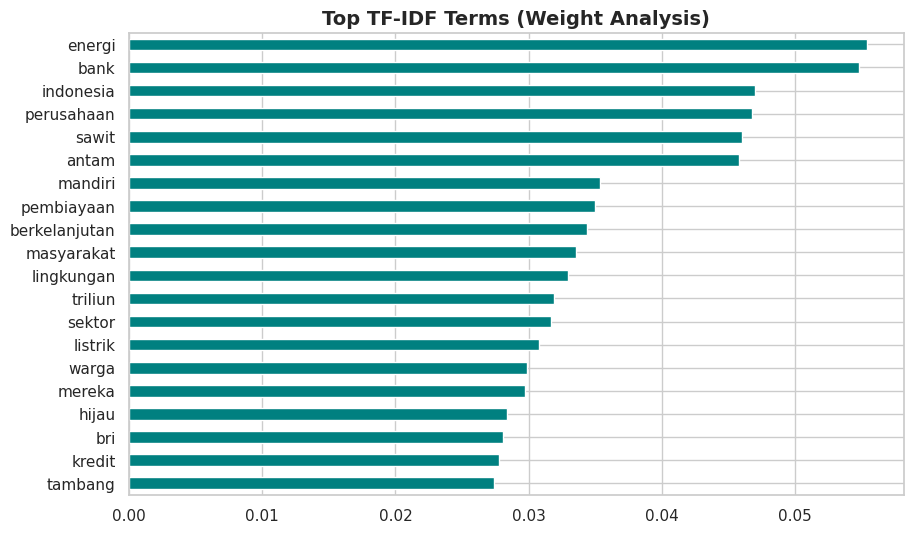

In [ ]:
print('\n⏳ [C0] Menghitung TF-IDF...')

from sklearn.feature_extraction.text import TfidfVectorizer

# Stopwords sederhana (biar konsisten sama n-gram kamu)
stop_words_id = ['yang', 'dan', 'di', 'dari', 'ke', 'ini', 'itu', 'tidak', 'untuk', 'sebagai', 'kami', 'atau',
                 'dengan', 'telah', 'dalam', 'pada', 'oleh', 'juga', 'akan', 'pt', 'tbk', 'menjadi', 'tersebut', 'lebih', 'salah satu', 'salah satunya', 'tahun']


# 1. STANDARISASI KOLOM (Biar ga KeyError lagi)
if 'clean_text' not in df.columns:
    kandidat = ['teks_bersih', 'Isi Berita', 'text', 'content']
    for k in kandidat:
        if k in df.columns:
            df.rename(columns={k: 'clean_text'}, inplace=True)
            print(f"✅ Kolom '{k}' berhasil dikenali sebagai 'clean_text'")
            break

# 2. EKSEKUSI TF-IDF
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words=stop_words_id
)
tfidf_matrix = tfidf.fit_transform(df['clean_text'].astype(str))

# Ambil fitur untuk plotting (hanya variabel lokal)
feature_names = tfidf.get_feature_names_out()
mean_tfidf = pd.Series(tfidf_matrix.toarray().mean(axis=0), index=feature_names).sort_values(ascending=False)

print('\n🔥 Top 20 Kata Berdasarkan TF-IDF:')
print(mean_tfidf.head(20))

# Plotting TF-IDF
plt.figure(figsize=(10, 6))
mean_tfidf.head(20).plot(kind='barh', color='teal')
plt.title('Top TF-IDF Terms (Weight Analysis)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

### N Gram


⏳ [C2] Ekstraksi Bigram & Trigram dengan CountVectorizer...


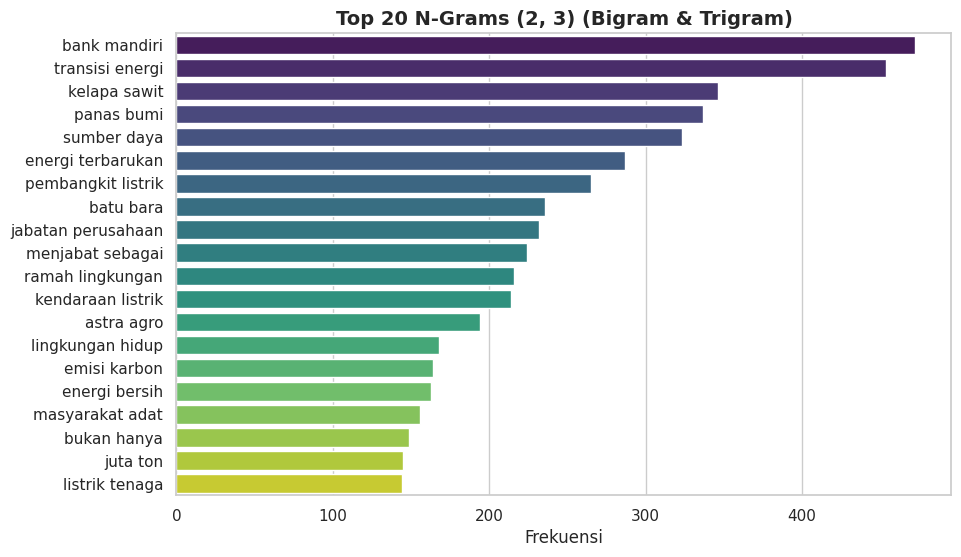

In [ ]:
print('\n⏳ [C2] Ekstraksi Bigram & Trigram dengan CountVectorizer...')

def plot_top_ngrams(df, ngram_range=(2,3), top_n=20):
    """Fungsi untuk mengekstrak dan plot n-gram menggunakan scikit-learn."""

    stop_words_id = ['yang', 'dan', 'di', 'dari', 'ke', 'ini', 'itu', 'untuk',
                     'dengan', 'dalam', 'pada', 'oleh', 'juga', 'akan', 'pt', 'tbk']

    blacklist_ngrams = {
        "salah satu", "jangka panjang", "2022 lalu", "salah satunya",
        "tata kelola", "kerja sama", "direktur utama", "tidak hanya", "sebagai bagian", "tidak ada", "bagi masyarakat"
    }

    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words=stop_words_id)

    # Ambil teks, pastikan dalam bentuk string
    corpus = df['clean_text'].astype(str).tolist()

    try:
        X = vectorizer.fit_transform(corpus)
        # Hitung frekuensi tiap n-gram
        sum_words = X.sum(axis=0)

        # Ambil semua n-gram dan frekuensinya
        all_words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]

        # FILTER: Buang n-gram yang ada di daftar blacklist
        words_freq_filtered = [wf for wf in all_words_freq if wf[0] not in blacklist_ngrams]

        # Urutkan dari yang frekuensinya paling besar, lalu potong sebanyak top_n (Top 20)
        words_freq = sorted(words_freq_filtered, key=lambda x: x[1], reverse=True)[:top_n]

        # Plotting
        if not words_freq:
            print("Tidak ada n-gram yang tersisa setelah di-filter.")
            return

        words, freqs = zip(*words_freq)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=list(freqs), y=list(words), palette="viridis")
        plt.title(f'Top {top_n} N-Grams {ngram_range} (Bigram & Trigram)', fontsize=14, fontweight='bold')
        plt.xlabel('Frekuensi')
        plt.show()

    except ValueError:
        print("Dataset terlalu kecil atau tidak ada kombinasi kata yang memenuhi syarat.")

# Panggil fungsinya untuk melihat visualisasinya (langsung top 20)
plot_top_ngrams(df, ngram_range=(2,3), top_n=20)

# Analisis Linguistik

In [ ]:
!pip install -q transformers torch

from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict

# Load IndoBERT POS Tagger (model khusus Bahasa Indonesia)
print("⏳ Loading IndoBERT POS Tagger...")
MODEL_NAME = "w11wo/indonesian-roberta-base-posp-tagger"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)
pos_pipe  = pipeline("token-classification", model=model, tokenizer=tokenizer,
                     aggregation_strategy="simple")

print("✅ Model berhasil dimuat!")

⏳ Loading IndoBERT POS Tagger...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Model berhasil dimuat!


In [ ]:
import ast
import json
import re
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification

# ── Load Model POS ──
print("⏳ Loading IndoBERT POS Tagger...")
MODEL_NAME = "w11wo/indonesian-roberta-base-posp-tagger"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)

# ✅ Pakai CPU — model ini konflik dengan CUDA Colab
pos_pipe = pipeline("token-classification", model=model, tokenizer=tokenizer,
                    aggregation_strategy="simple", device=-1)
print("✅ Model loaded!")

def parse_tokens(token_list):
    if isinstance(token_list, list):
        return token_list
    if not isinstance(token_list, str) or not token_list.strip():
        return []
    try:
        return json.loads(token_list)
    except:
        pass
    try:
        return ast.literal_eval(token_list)
    except:
        pass
    tokens = re.findall(r'"([^"]*)"', token_list)
    return tokens if tokens else []

def pos_tag_indobert(token_list):
    tokens = parse_tokens(token_list)
    if not tokens:
        return []
    try:
        result = pos_pipe(" ".join(tokens[:128]))
        return [(r['word'], r['entity_group']) for r in result]
    except Exception as e:
        return []

print("\n⏳ Memproses POS Tagging seluruh dataset (CPU ~10-20 menit)...")
df['pos_indobert'] = df['tokens'].apply(pos_tag_indobert)

# Cek hasil
total_filled = df['pos_indobert'].apply(lambda x: len(x) > 0).sum()
print(f"✅ Selesai! {total_filled}/{len(df)} artikel berhasil di-tag")
print(f"Contoh hasil: {df['pos_indobert'].iloc[0][:10]}")

⏳ Loading IndoBERT POS Tagger...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Model loaded!

Test parse: 222 token → ['sukses', 'transisi', 'energi', 'salah', 'tuju']
Test POS: [(' sukses', 'ADJ'), (' transisi', 'NNO'), (' energi', 'NNO'), (' salah', 'ADJ'), (' tuju', 'NNP')]

⏳ Memproses POS Tagging seluruh dataset (CPU ~10-20 menit)...
✅ Selesai! 468/468 artikel berhasil di-tag
Contoh hasil: [(' sukses', 'ADJ'), (' transisi', 'NNO'), (' energi', 'NNO'), (' salah', 'NNP'), (' tuju', 'NNP'), (' isu', 'NNO'), (' s', 'NNP'), ('ustainable', 'NNP'), (' fin', 'NNP'), ('ancing', 'NNP')]


Label tersedia: ['Noun', 'Verb', 'Adjective', 'Adverb', 'Proper Noun', 'Negation', 'Conjunction']


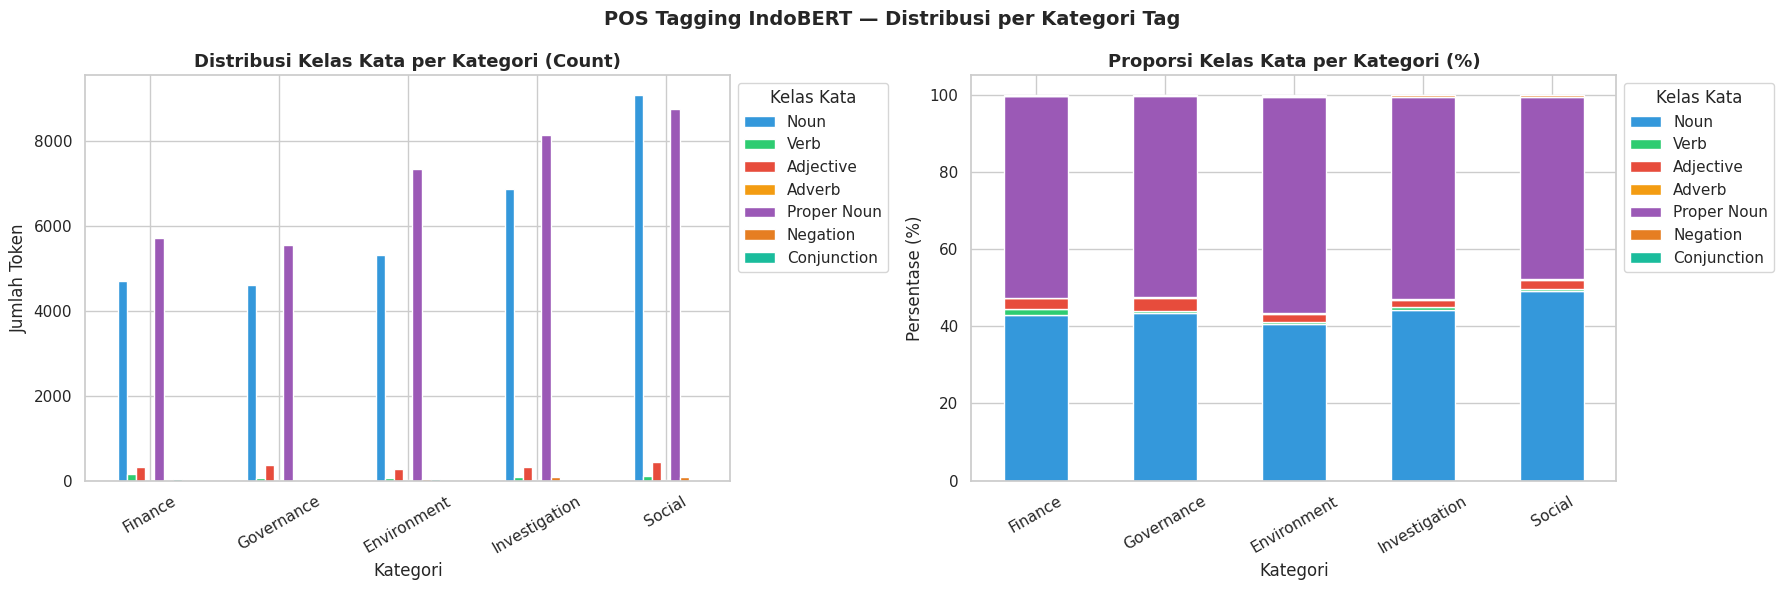


Label asli dari model:
[('NNP', 35473), ('NNO', 30595), ('NUM', 5368), ('ADJ', 1715), ('VBI', 428), ('PPO', 258), ('NEG', 240), ('CCN', 119), ('SYM', 70), ('$$$', 55), ('VBT', 33), ('ADV', 32), ('VBE', 20), ('VBP', 12), ('KUA', 12), ('ADK', 11), ('UNS', 9), ('CSN', 7), ('ART', 4), ('PRR', 2), ('PAR', 1)]


In [ ]:
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

POS_LABEL_MAP = {
    'NNP': 'Proper Noun', 'NNO': 'Noun', 'NND': 'Noun',
    'VBT': 'Verb', 'VBI': 'Verb', 'VBP': 'Verb', 'VBL': 'Verb', 'VBE': 'Verb',
    'ADJ': 'Adjective', 'ADV': 'Adverb', 'ADK': 'Adverb',
    'PPO': 'Pronoun', 'PRR': 'Pronoun', 'PRN': 'Pronoun', 'PRI': 'Pronoun', 'PRK': 'Pronoun',
    'CCN': 'Conjunction', 'CSN': 'Conjunction',
    'ART': 'Particle', 'PAR': 'Particle',
    'KUA': 'Quantifier', 'NUM': 'Number',
    'NEG': 'Negation', 'SYM': 'Symbol', 'UNS': 'Other', '$$$': 'Other',
}
MAIN_POS   = ['Noun', 'Verb', 'Adjective', 'Adverb', 'Proper Noun', 'Negation', 'Conjunction']
POS_COLORS = {
    'Noun': '#3498db', 'Verb': '#2ecc71', 'Adjective': '#e74c3c',
    'Adverb': '#f39c12', 'Proper Noun': '#9b59b6',
    'Negation': '#e67e22', 'Conjunction': '#1abc9c',
}

def map_pos(tag):
    return POS_LABEL_MAP.get(tag, 'Other')

# Cek label yang tersedia
all_mapped   = [map_pos(pos) for row in df['pos_indobert'] for _, pos in row]
available_pos = [p for p in MAIN_POS if p in set(all_mapped)]
print(f"Label tersedia: {available_pos}")

# Hitung per Tag
pos_by_tag = defaultdict(Counter)
for _, row in df.iterrows():
    tag = str(row['Tag'])
    for _, pos in row['pos_indobert']:
        mapped = map_pos(pos)
        if mapped in available_pos:
            pos_by_tag[tag][mapped] += 1

pos_df  = pd.DataFrame(pos_by_tag).T.fillna(0).astype(int)
pos_df  = pos_df[[c for c in available_pos if c in pos_df.columns]]
pos_pct = pos_df.div(pos_df.sum(axis=1), axis=0) * 100

colors_used = [POS_COLORS[p] for p in pos_df.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
pos_df.plot(kind='bar', ax=axes[0], color=colors_used, edgecolor='white')
axes[0].set_title('Distribusi Kelas Kata per Kategori (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Token')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Kelas Kata', bbox_to_anchor=(1, 1))

pos_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colors_used, edgecolor='white')
axes[1].set_title('Proporsi Kelas Kata per Kategori (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Persentase (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Kelas Kata', bbox_to_anchor=(1, 1))

plt.suptitle('POS Tagging IndoBERT — Distribusi per Kategori Tag', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pos_distribusi_indobert.png', bbox_inches='tight')
plt.show()

print("\nLabel asli dari model:")
raw_labels = Counter(pos for row in df['pos_indobert'] for _, pos in row)
print(raw_labels.most_common())

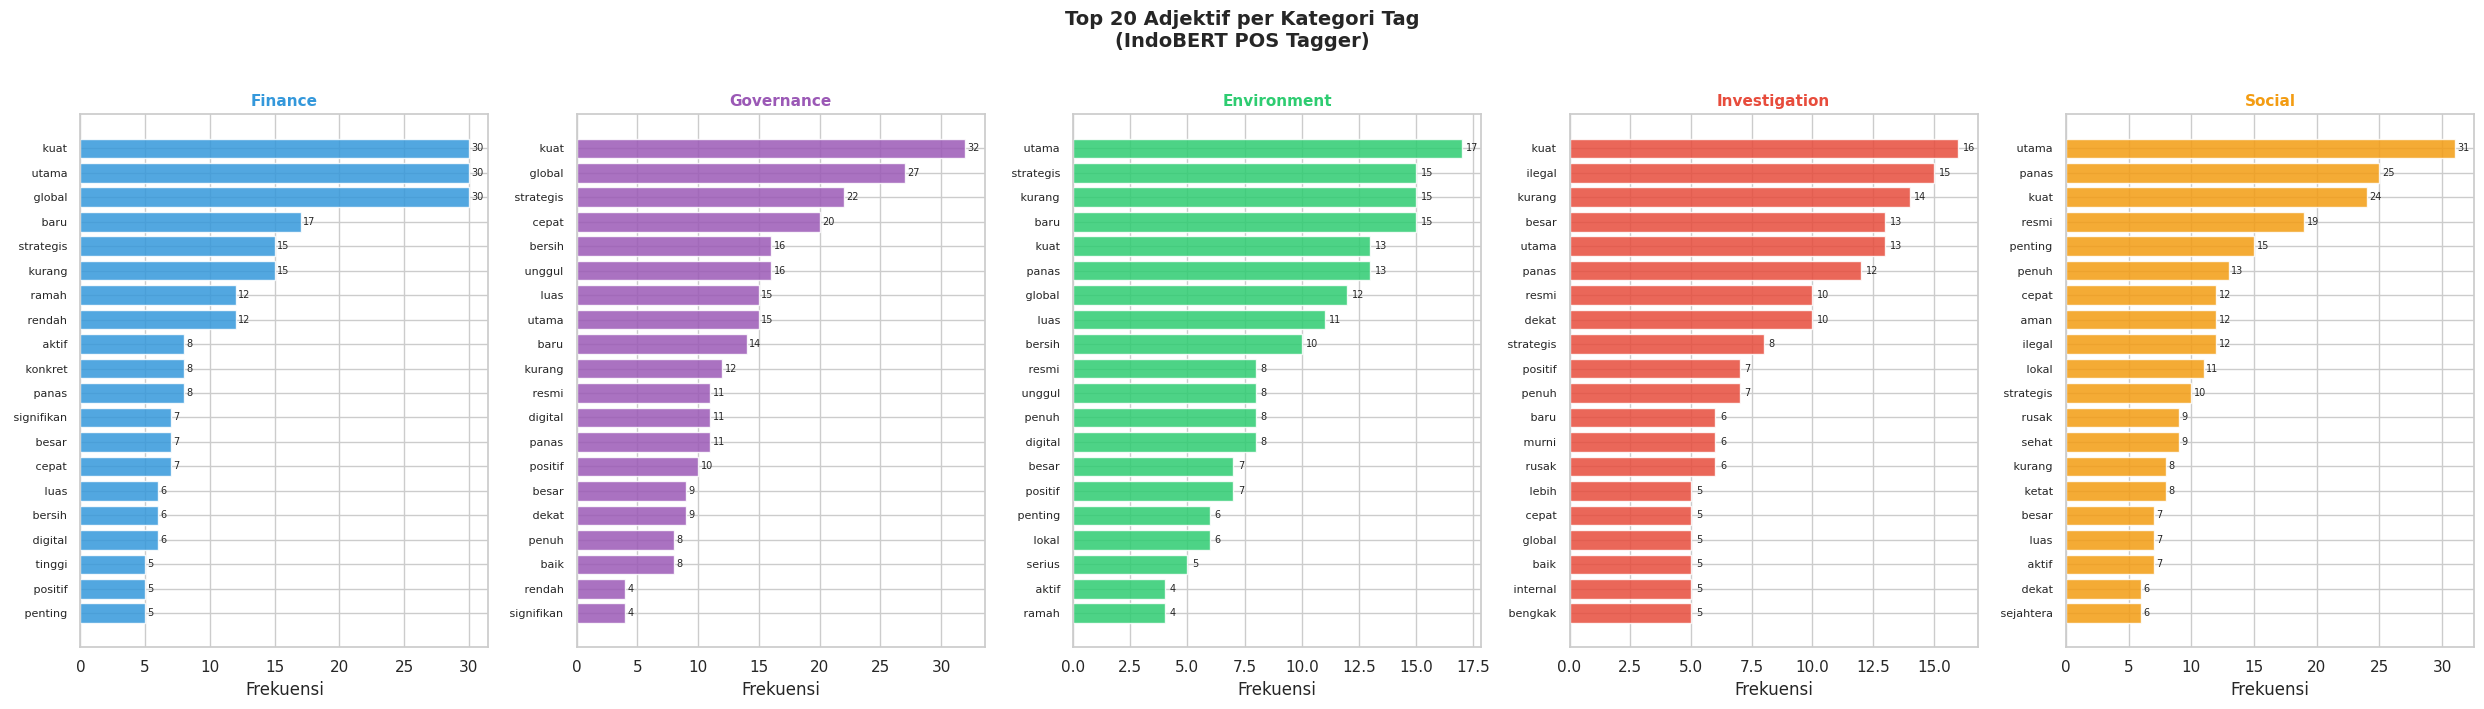

In [ ]:
TAG_COLORS_MAP = {
    'Environment':   '#2ecc71',
    'Finance':       '#3498db',
    'Governance':    '#9b59b6',
    'Investigation': '#e74c3c',
    'Social':        '#f39c12'
}

TAGS = df['Tag'].dropna().unique()

def top_adj_by_tag(df, tag, top_n=20):
    subset = df[df['Tag'] == tag]
    adjs = [
        word for row in subset['pos_indobert']
        for word, pos in row
        if map_pos(pos) == 'Adjective' and len(word) > 2
    ]
    return Counter(adjs).most_common(top_n)

fig, axes = plt.subplots(1, len(TAGS), figsize=(5 * len(TAGS), 7))
fig.suptitle('Top 20 Adjektif per Kategori Tag\n(IndoBERT POS Tagger)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, tag in zip(axes, TAGS):
    top = top_adj_by_tag(df, tag, 20)
    if not top:
        ax.text(0.5, 0.5, f'Tidak ada\nadjektif', ha='center', va='center',
                transform=ax.transAxes, fontsize=11)
        ax.set_title(tag, fontsize=11, fontweight='bold',
                     color=TAG_COLORS_MAP.get(tag, '#95a5a6'))
        ax.axis('off')
        continue
    words, counts = zip(*top)
    color = TAG_COLORS_MAP.get(tag, '#95a5a6')
    bars = ax.barh(list(words)[::-1], list(counts)[::-1],
                   color=color, alpha=0.85, edgecolor='white')
    ax.set_title(tag, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Frekuensi')
    ax.tick_params(axis='y', labelsize=8)
    for bar, cnt in zip(bars, list(counts)[::-1]):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                str(cnt), va='center', fontsize=7)

plt.tight_layout()
plt.savefig('adjektif_per_tag_indobert.png', bbox_inches='tight')
plt.show()

### NER using IndoBERT

In [ ]:
import ast
import json
import re
from transformers import pipeline

# Load NER model
print("⏳ Loading IndoBERT NER...")
ner_pipeline = pipeline("ner", model="cahya/bert-base-indonesian-NER",
                        aggregation_strategy="simple", device=-1)
print("✅ NER model loaded!")

def parse_tokens(token_list):
    if isinstance(token_list, list):
        return token_list
    if not isinstance(token_list, str) or not token_list.strip():
        return []
    try:
        return json.loads(token_list)
    except:
        pass
    try:
        return ast.literal_eval(token_list)
    except:
        pass
    tokens = re.findall(r'"([^"]*)"', token_list)
    return tokens if tokens else []

def ekstrak_indobert_ner(token_list):
    tokens = parse_tokens(token_list)
    if not tokens:
        return "", ""
    text = " ".join(tokens[:100])
    try:
        hasil_ner = ner_pipeline(text)
    except Exception:
        return "", ""
    orgs, locs = set(), set()
    for ent in hasil_ner:
        if ent['entity_group'] == 'ORG':
            orgs.add(ent['word'])
        elif ent['entity_group'] == 'LOC':
            locs.add(ent['word'])
    return ", ".join(list(orgs)), ", ".join(list(locs))

# Test 1 baris dulu
sample_parsed = parse_tokens(df['tokens'].iloc[0])
print(f"\nTest parse: {len(sample_parsed)} token → {sample_parsed[:5]}")
test_org, test_loc = ekstrak_indobert_ner(df['tokens'].iloc[0])
print(f"Test NER → ORG: {test_org} | LOC: {test_loc}")

# Jalankan ke seluruh df
print("\n⏳ Memproses NER seluruh dataset...")
df[['IndoBERT_ORG', 'IndoBERT_LOC']] = df.apply(
    lambda row: pd.Series(ekstrak_indobert_ner(row['tokens'])), axis=1
)
print("✅ NER selesai!")
display(df[['IndoBERT_ORG', 'IndoBERT_LOC']].head(5))

⏳ Loading IndoBERT NER...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ NER model loaded!

Test parse: 222 token → ['sukses', 'transisi', 'energi', 'salah', 'tuju']
Test NER → ORG: ##ib, ndc national, pt bank rakyat indonesia persero tbk bri bank, solichin, indonesia, 5, direktur, lingkung, end, triliun, bri, buku | LOC: 

⏳ Memproses NER seluruh dataset...
✅ NER selesai!


,IndoBERT_ORG,IndoBERT_LOC
0,"##ib, ndc national, pt bank rakyat indonesia p...",
1,"bank sandi saham bmri, bank mandiri, ##andar, ...",
2,"bank mandiri cermin persero, bank mandiri, cor...",
3,bank mandiri,
4,"bank syariah, direktur utama bsi, pt bank syar...",


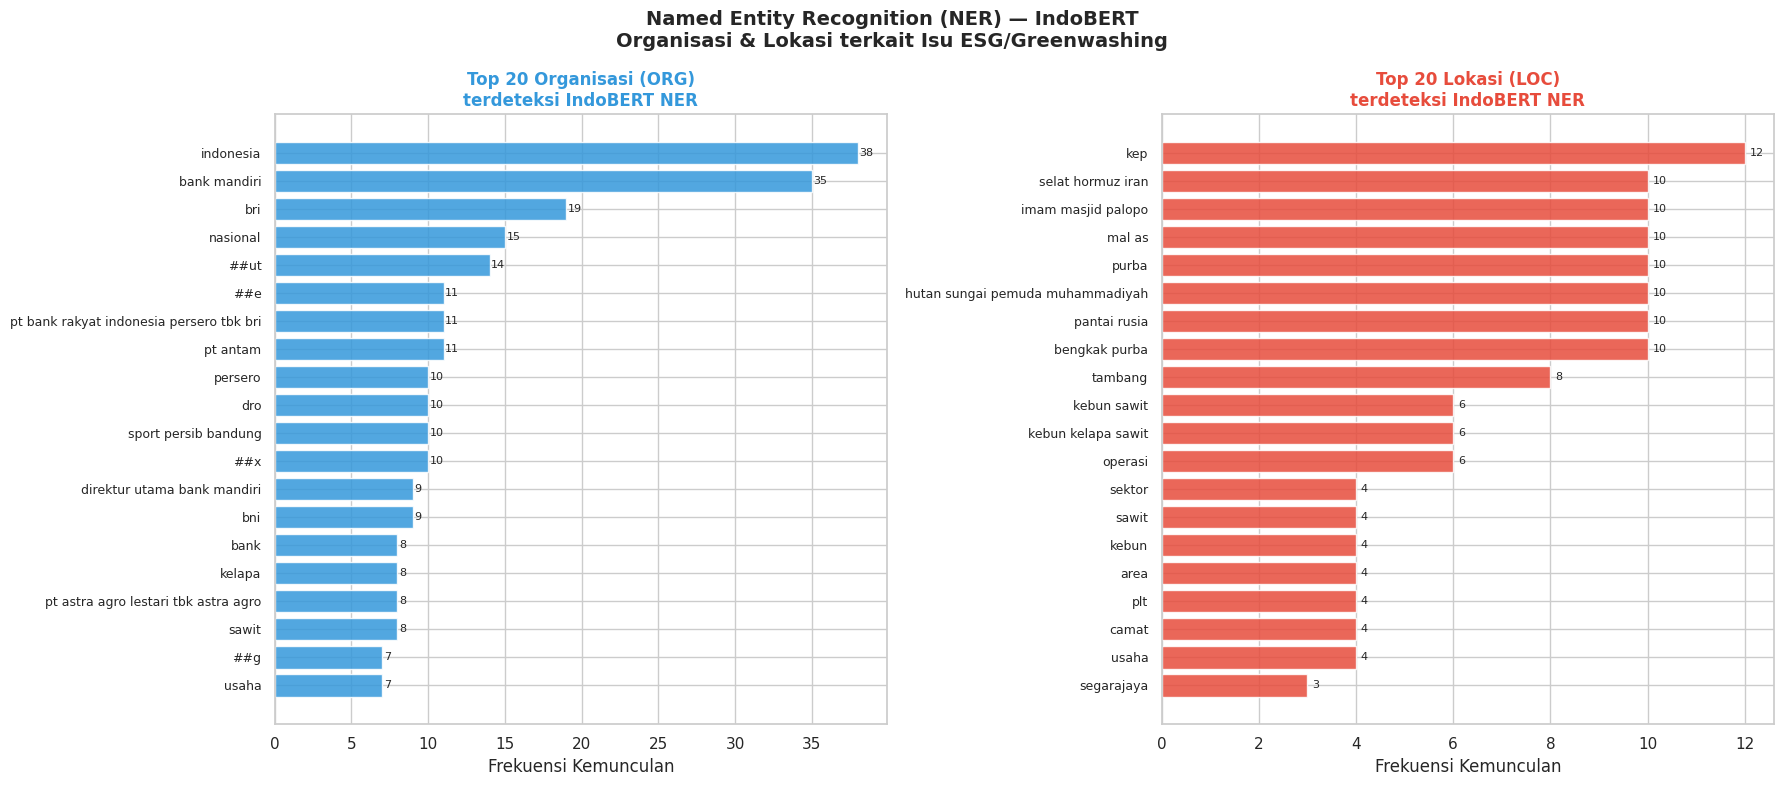

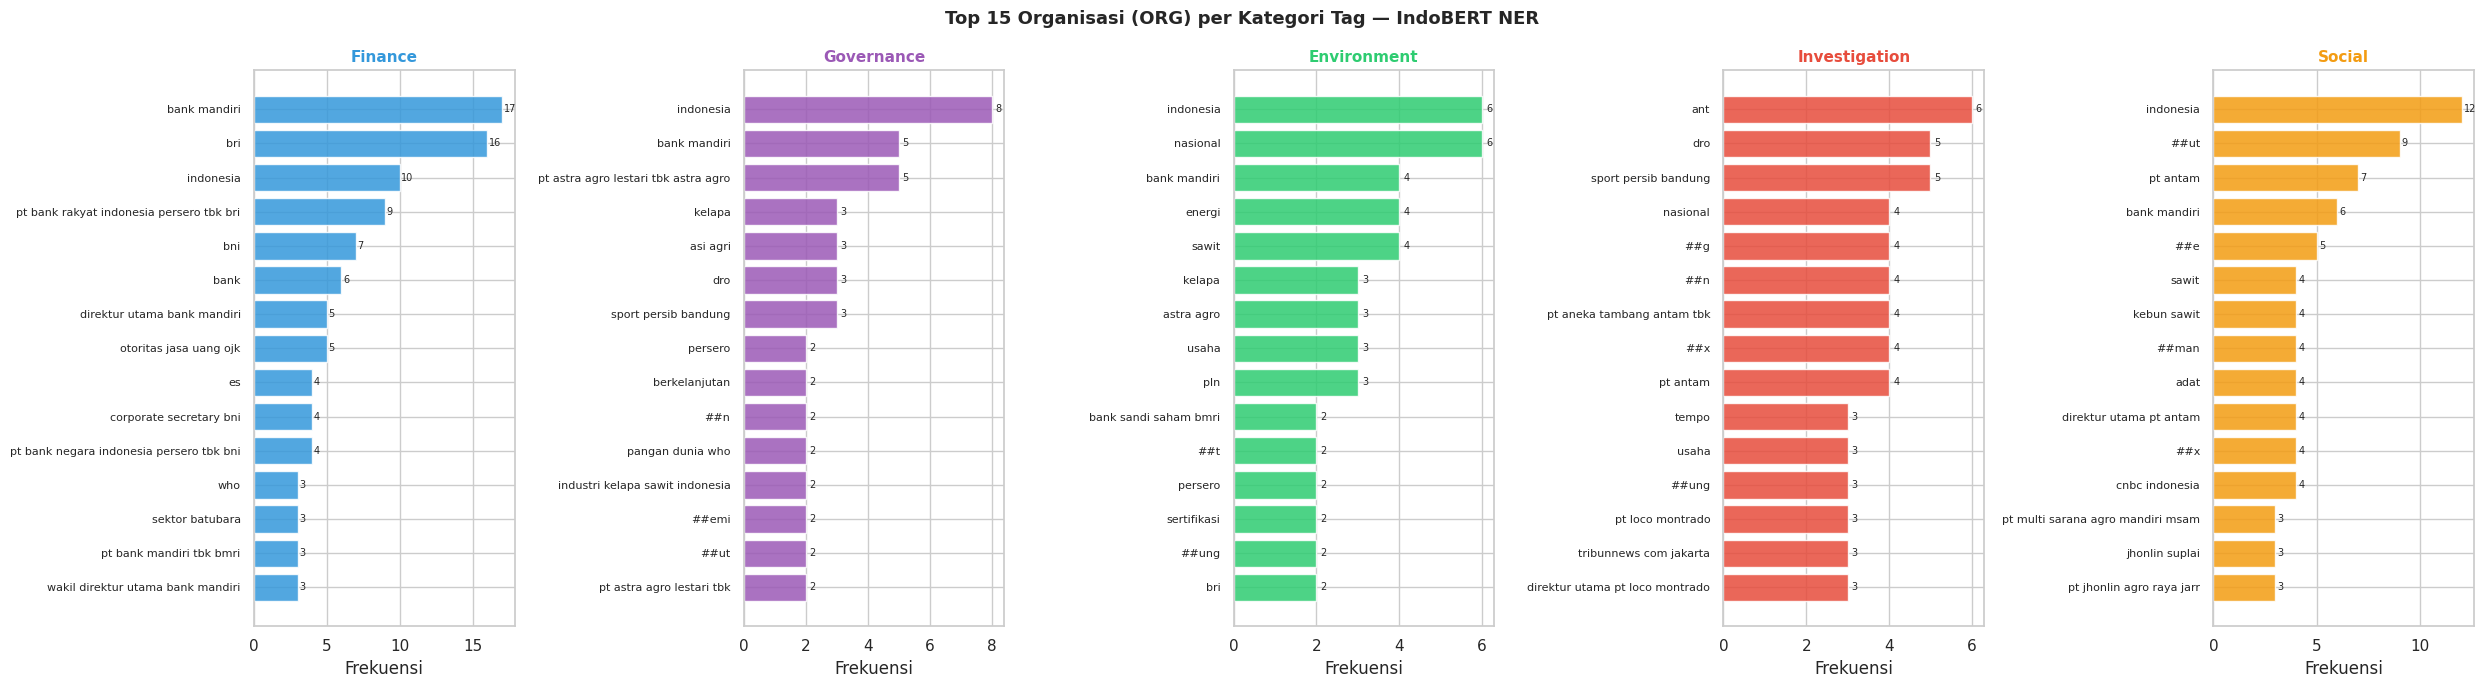

✅ Visualisasi NER tersimpan!


In [ ]:
# ── Visualisasi Top ORG & LOC ──
from collections import Counter

# Pecah string kembali jadi list, buang yang kosong
all_orgs = [o.strip() for orgs in df['IndoBERT_ORG'] for o in orgs.split(',') if o.strip()]
all_locs = [l.strip() for locs in df['IndoBERT_LOC'] for l in locs.split(',') if l.strip()]

top_orgs = Counter(all_orgs).most_common(20)
top_locs = Counter(all_locs).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot ORG
if top_orgs:
    words, counts = zip(*top_orgs)
    bars = axes[0].barh(list(words)[::-1], list(counts)[::-1],
                        color='#3498db', alpha=0.85, edgecolor='white')
    axes[0].set_title('Top 20 Organisasi (ORG)\nterdeteksi IndoBERT NER',
                      fontsize=12, fontweight='bold', color='#3498db')
    axes[0].set_xlabel('Frekuensi Kemunculan')
    axes[0].tick_params(axis='y', labelsize=9)
    for bar, cnt in zip(bars, list(counts)[::-1]):
        axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                     str(cnt), va='center', fontsize=8)

# Plot LOC
if top_locs:
    words, counts = zip(*top_locs)
    bars2 = axes[1].barh(list(words)[::-1], list(counts)[::-1],
                         color='#e74c3c', alpha=0.85, edgecolor='white')
    axes[1].set_title('Top 20 Lokasi (LOC)\nterdeteksi IndoBERT NER',
                      fontsize=12, fontweight='bold', color='#e74c3c')
    axes[1].set_xlabel('Frekuensi Kemunculan')
    axes[1].tick_params(axis='y', labelsize=9)
    for bar, cnt in zip(bars2, list(counts)[::-1]):
        axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                     str(cnt), va='center', fontsize=8)

plt.suptitle('Named Entity Recognition (NER) — IndoBERT\nOrganisasi & Lokasi terkait Isu ESG/Greenwashing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ner_org_loc_indobert.png', bbox_inches='tight')
plt.show()

# ── Bonus: ORG per Kategori Tag ──
fig, axes = plt.subplots(1, len(df['Tag'].dropna().unique()), figsize=(5 * len(df['Tag'].dropna().unique()), 7))

TAG_COLORS_MAP = {
    'Environment':   '#2ecc71',
    'Finance':       '#3498db',
    'Governance':    '#9b59b6',
    'Investigation': '#e74c3c',
    'Social':        '#f39c12'
}

for ax, tag in zip(axes, df['Tag'].dropna().unique()):
    subset_orgs = [
        o.strip()
        for orgs in df[df['Tag']==tag]['IndoBERT_ORG']
        for o in orgs.split(',') if o.strip()
    ]
    top = Counter(subset_orgs).most_common(15)
    if not top:
        ax.set_visible(False)
        continue
    words, counts = zip(*top)
    color = TAG_COLORS_MAP.get(tag, '#95a5a6')
    bars = ax.barh(list(words)[::-1], list(counts)[::-1],
                   color=color, alpha=0.85, edgecolor='white')
    ax.set_title(tag, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Frekuensi')
    ax.tick_params(axis='y', labelsize=8)
    for bar, cnt in zip(bars, list(counts)[::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(cnt), va='center', fontsize=7)

plt.suptitle('Top 15 Organisasi (ORG) per Kategori Tag — IndoBERT NER',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ner_org_per_tag.png', bbox_inches='tight')
plt.show()
print('✅ Visualisasi NER tersimpan!')

In [ ]:
print('\n⏳ Menyimpan hasil ke CSV...')
df.to_csv('IndoBERT.csv', index=False)
print('✅ File berhasil dibuat')


⏳ Menyimpan hasil ke CSV...
✅ File berhasil dibuat
